# 02 -- ENSO ONI Signal: L2b Backtest

Validates the L2b climate signal: NOAA Oceanic Nino Index (ONI) with a 24-month lag
predicts Arabica price direction.

**Thesis:** La Nina (negative ONI) causes drought in Brazil and Vietnam, reducing
coffee supply ~18-24 months later, which pushes prices up.

**Gate (L2b):** r(ONI lagged 24m, Arabica price) <= -0.20 on real data 2010-2024

| Metric | Threshold | Direction |
|--------|-----------|----------|
| Pearson r at 24m lag | <= -0.20 | Negative: low ONI -> high price |


## Sec 0  Setup


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')


In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402


In [3]:
from domains.coffee.sources.noaa_enso import (
    enso_risk_score,  # noqa: E402
    fetch,  # noqa: E402
)


## Sec 1  Fetch NOAA ONI Data


In [4]:
# Fetch from 1980 to give plenty of history for the 24m lag
START = date(1980, 1, 1)
END   = date(2025, 12, 31)

obs, run = fetch(START, END)
print(f'Status : {run.status}')
print(f'Records: {run.records_fetched}')
if run.error_message:
    print(f'Warning: {run.error_message}')


Status : RunStatus.SUCCESS
Records: 552


In [5]:
oni_df = pd.DataFrame(
    [{'date': o.observed_date, 'oni_anom': o.value} for o in obs]
).set_index('date')
oni_df.index = pd.to_datetime(oni_df.index)
oni_df = oni_df.sort_index()

print(f'ONI: {len(oni_df)} months, '
      f'{oni_df.index[0].date()} to {oni_df.index[-1].date()}')
print(f'Range: [{oni_df["oni_anom"].min():.2f}, '
       f'{oni_df["oni_anom"].max():.2f}] degC')
oni_df.tail(6)


ONI: 552 months, 1980-01-31 to 2025-12-31
Range: [-1.85, 2.75] degC


,oni_anom
date,
2025-07-31,-0.04
2025-08-31,-0.14
2025-09-30,-0.28
2025-10-31,-0.40
2025-11-30,-0.51
2025-12-31,-0.55


## Sec 2  Load ICE KC=F Reference Data


In [6]:
kc_df = pd.read_csv(
    'data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date'
)
print(f'KC=F: {len(kc_df)} months, '
      f'{kc_df.index[0].date()} to {kc_df.index[-1].date()}')


KC=F: 221 months, 2008-01-31 to 2026-05-31


## Sec 3  Visual Inspection: ONI vs Arabica Price

Do we see a visual inverse relationship with a lag?


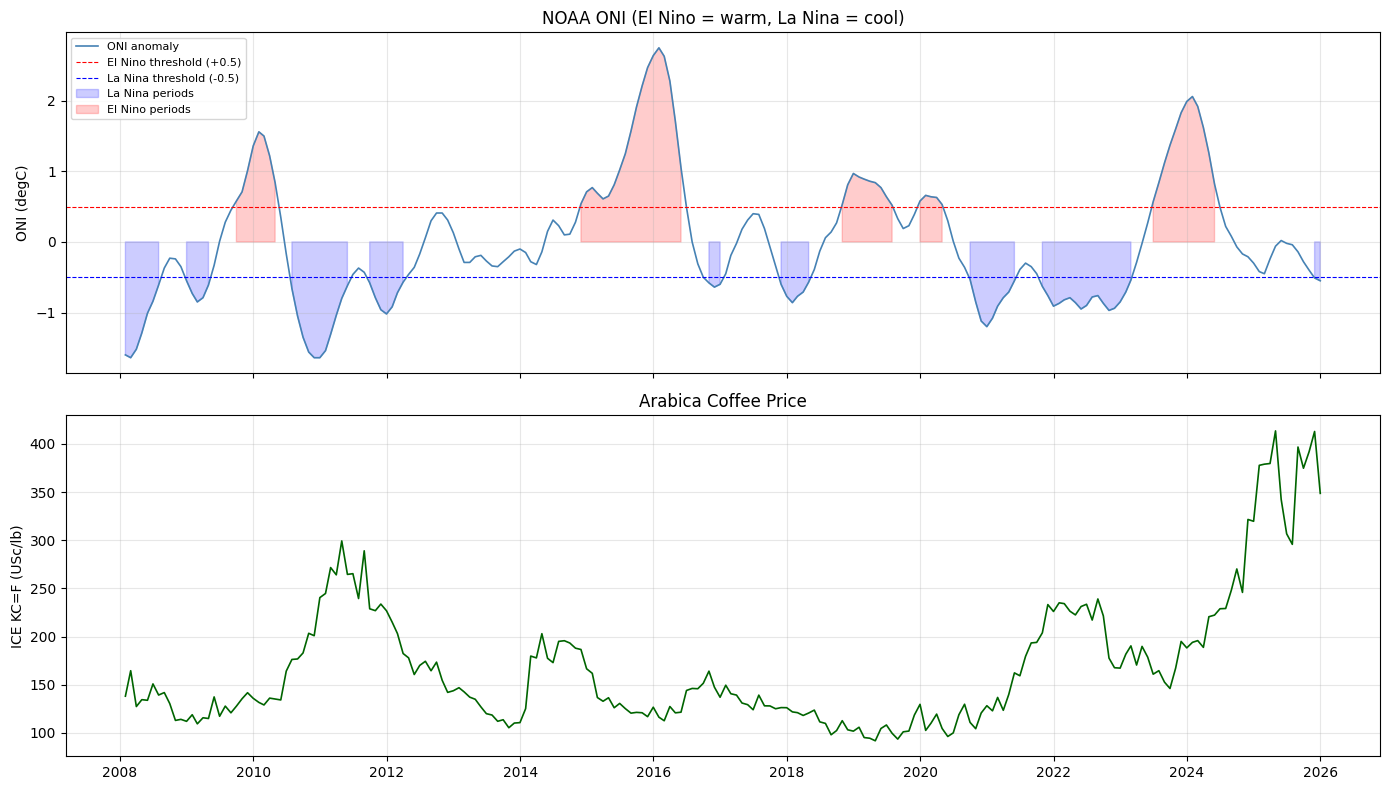

Saved: data/02_oni_vs_price.png


In [7]:
merged_all = kc_df[['settle']].join(oni_df, how='inner').dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ONI with El Nino / La Nina shading
axes[0].plot(merged_all.index, merged_all['oni_anom'],
             color='steelblue', lw=1.2, label='ONI anomaly')
axes[0].axhline(0.5,  color='red',  linestyle='--', lw=0.8,
                label='El Nino threshold (+0.5)')
axes[0].axhline(-0.5, color='blue', linestyle='--', lw=0.8,
                label='La Nina threshold (-0.5)')
axes[0].fill_between(merged_all.index, merged_all['oni_anom'], 0,
                     where=merged_all['oni_anom'] < -0.5,
                     alpha=0.2, color='blue', label='La Nina periods')
axes[0].fill_between(merged_all.index, merged_all['oni_anom'], 0,
                     where=merged_all['oni_anom'] > 0.5,
                     alpha=0.2, color='red', label='El Nino periods')
axes[0].set_ylabel('ONI (degC)')
axes[0].set_title('NOAA ONI (El Nino = warm, La Nina = cool)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(merged_all.index, merged_all['settle'],
             color='darkgreen', lw=1.2)
axes[1].set_ylabel('ICE KC=F (USc/lb)')
axes[1].set_title('Arabica Coffee Price')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/02_oni_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_oni_vs_price.png')


## Sec 4  Lag Analysis: Correlation at Each Lag (0 to 36 months)

Sweep lags to find where ONI has maximum predictive power.
Expected peak: around 18-24 months (growing season + supply chain delay).


In [8]:
core = merged_all.loc['2010-01-01':'2024-12-31'].copy()
core['kc_yoy'] = core['settle'].pct_change(12) * 100

lags = range(0, 37)
r_price, r_yoy = [], []

for lag in lags:
    lagged_oni = merged_all['oni_anom'].shift(lag)
    # Align to core window after shift
    df_lag = core.join(
        lagged_oni.rename('oni_lag'), how='left'
    ).dropna(subset=['oni_lag', 'settle', 'kc_yoy'])
    if len(df_lag) < 30:
        r_price.append(np.nan)
        r_yoy.append(np.nan)
        continue
    rp, _ = stats.pearsonr(df_lag['oni_lag'], df_lag['settle'])
    ry, _ = stats.pearsonr(df_lag['oni_lag'], df_lag['kc_yoy'])
    r_price.append(rp)
    r_yoy.append(ry)

lag_df = pd.DataFrame({'lag': lags, 'r_price': r_price, 'r_yoy': r_yoy})
print('Lag (m)  r(ONI, price level)  r(ONI, YoY change)')
for _, row in lag_df.iterrows():
    print(
        f"  {int(row['lag']):2d}m      {row['r_price']:+.3f}             "
        f"{row['r_yoy']:+.3f}"
    )


Lag (m)  r(ONI, price level)  r(ONI, YoY change)
   0m      -0.338             -0.357
   1m      -0.338             -0.336
   2m      -0.331             -0.305
   3m      -0.316             -0.264
   4m      -0.296             -0.215
   5m      -0.273             -0.161
   6m      -0.249             -0.105
   7m      -0.222             -0.046
   8m      -0.194             +0.013
   9m      -0.167             +0.070
  10m      -0.141             +0.126
  11m      -0.120             +0.180
  12m      -0.106             +0.227
  13m      -0.096             +0.261
  14m      -0.088             +0.280
  15m      -0.079             +0.288
  16m      -0.073             +0.286
  17m      -0.067             +0.276
  18m      -0.064             +0.262
  19m      -0.063             +0.242
  20m      -0.069             +0.216
  21m      -0.081             +0.181
  22m      -0.096             +0.141
  23m      -0.112             +0.101
  24m      -0.127             +0.065
  25m      -0.142         

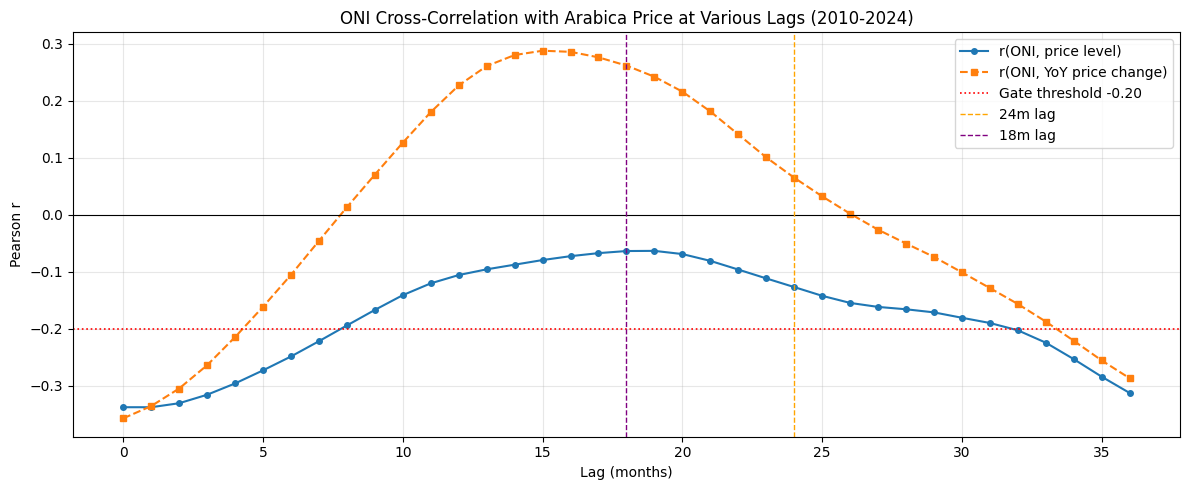

Saved: data/02_lag_correlation.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lags, r_price, marker='o', ms=4, label='r(ONI, price level)', lw=1.5)
ax.plot(lags, r_yoy, marker='s', ms=4,
        label='r(ONI, YoY price change)', lw=1.5, linestyle='--')
ax.axhline(-0.20, color='red', linestyle=':', lw=1.2, label='Gate threshold -0.20')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(24, color='orange', linestyle='--', lw=1, label='24m lag')
ax.axvline(18, color='purple', linestyle='--', lw=1, label='18m lag')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title(
    'ONI Cross-Correlation with Arabica Price at Various Lags (2010-2024)'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/02_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_lag_correlation.png')


## Sec 5  Gate Validation: r at 24m lag <= -0.20


In [10]:
core['oni_lag18'] = merged_all['oni_anom'].shift(18)
core['oni_lag24'] = merged_all['oni_anom'].shift(24)
valid = core.dropna(subset=['oni_lag18', 'oni_lag24', 'settle', 'kc_yoy'])

r18_price, p18 = stats.pearsonr(valid['oni_lag18'], valid['settle'])
r24_price, p24 = stats.pearsonr(valid['oni_lag24'], valid['settle'])
r18_yoy, _ = stats.pearsonr(valid['oni_lag18'], valid['kc_yoy'])
r24_yoy, _ = stats.pearsonr(valid['oni_lag24'], valid['kc_yoy'])

gate_pass = r24_price <= -0.20
g_str = 'PASS' if gate_pass else 'FAIL'

print(f'n = {len(valid)} months (2010-2024 core window)')
print()
print(f'18m lag: r(ONI, price level) = {r18_price:+.4f}')
print(f'18m lag: r(ONI, YoY change)  = {r18_yoy:+.4f}')
print()
print(f'24m lag: r(ONI, price level) = {r24_price:+.4f}  p={p24:.3e}')
print(f'24m lag: r(ONI, YoY change)  = {r24_yoy:+.4f}')
print()
print(f'Gate L2b (r at 24m <= -0.20): {g_str}')


n = 168 months (2010-2024 core window)

18m lag: r(ONI, price level) = -0.0636
18m lag: r(ONI, YoY change)  = +0.2617

24m lag: r(ONI, price level) = -0.1268  p=1.014e-01
24m lag: r(ONI, YoY change)  = +0.0650

Gate L2b (r at 24m <= -0.20): FAIL


## Sec 5b  Extended Window: WB Arabica 2000-2024 (more ENSO cycles)

KC=F only goes back to 2008 (15 yrs, ~1.5 full ENSO cycles).
WB Arabica goes back to 2000 (24 yrs, ~3 full cycles) giving more statistical power.


In [11]:
wb_df = pd.read_csv('data/wb_arabica_monthly.csv',
                    parse_dates=['date'], index_col='date')
wb_df = wb_df[['settle']].rename(columns={'settle': 'wb_price'})
print(f'WB Arabica: {len(wb_df)} months, '
      f'{wb_df.index[0].date()} to {wb_df.index[-1].date()}')

merged_wb = wb_df.join(oni_df, how='inner').dropna()
merged_wb['wb_yoy'] = merged_wb['wb_price'].pct_change(12) * 100

# Compute lag correlations on the 2000-2024 full window
lags_wb, r_wb_price, r_wb_yoy = [], [], []
for lag in range(0, 37):
    lagged = oni_df['oni_anom'].shift(lag)
    df_l = merged_wb.join(
        lagged.rename('oni_lag'), how='left'
    ).dropna(subset=['oni_lag', 'wb_price', 'wb_yoy'])
    if len(df_l) < 30:
        lags_wb.append(lag)
        r_wb_price.append(np.nan)
        r_wb_yoy.append(np.nan)
        continue
    rp, _ = stats.pearsonr(df_l['oni_lag'], df_l['wb_price'])
    ry, _ = stats.pearsonr(df_l['oni_lag'], df_l['wb_yoy'])
    lags_wb.append(lag)
    r_wb_price.append(rp)
    r_wb_yoy.append(ry)

# Gate check on WB extended window
merged_wb['oni_lag24'] = oni_df['oni_anom'].shift(24)
wb_core = merged_wb.loc['2000-01-01':'2024-12-31'].dropna(
    subset=['oni_lag24', 'wb_price', 'wb_yoy']
)
r24_wb, p24_wb = stats.pearsonr(wb_core['oni_lag24'], wb_core['wb_price'])
r18_wb, _ = stats.pearsonr(
    wb_core['oni_lag24'].shift(-6).reindex(wb_core.index),
    wb_core['wb_price']
)
gate_wb = r24_wb <= -0.20
g_wb = 'PASS' if gate_wb else 'FAIL'

print(f'WB Arabica 2000-2024, n={len(wb_core)}')
print(f'24m lag: r(ONI, WB price) = {r24_wb:+.4f}  p={p24_wb:.3e}')
print(f'Gate L2b (r24m <= -0.20): {g_wb}')


WB Arabica: 312 months, 2000-01-31 to 2025-12-31


WB Arabica 2000-2024, n=288
24m lag: r(ONI, WB price) = +0.0330  p=5.767e-01
Gate L2b (r24m <= -0.20): FAIL


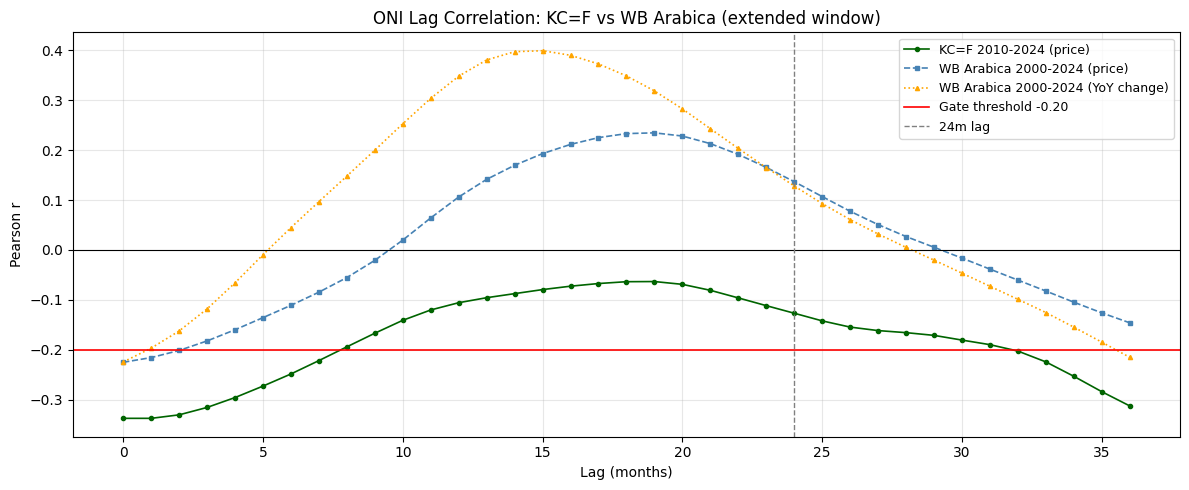

Saved: data/02_lag_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lags, r_price, marker='o', ms=3,
        label='KC=F 2010-2024 (price)', lw=1.2, color='darkgreen')
ax.plot(lags_wb, r_wb_price, marker='s', ms=3,
        label='WB Arabica 2000-2024 (price)', lw=1.2,
        linestyle='--', color='steelblue')
ax.plot(lags_wb, r_wb_yoy, marker='^', ms=3,
        label='WB Arabica 2000-2024 (YoY change)', lw=1.2,
        linestyle=':', color='orange')
ax.axhline(-0.20, color='red', linestyle='-', lw=1.2,
           label='Gate threshold -0.20')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(24, color='gray', linestyle='--', lw=1, label='24m lag')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('ONI Lag Correlation: KC=F vs WB Arabica (extended window)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/02_lag_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_lag_comparison.png')


## Sec 6  Risk Score Distribution

Show how `enso_risk_score()` maps historical ONI values to the 0-1 risk scale
used in the composite.


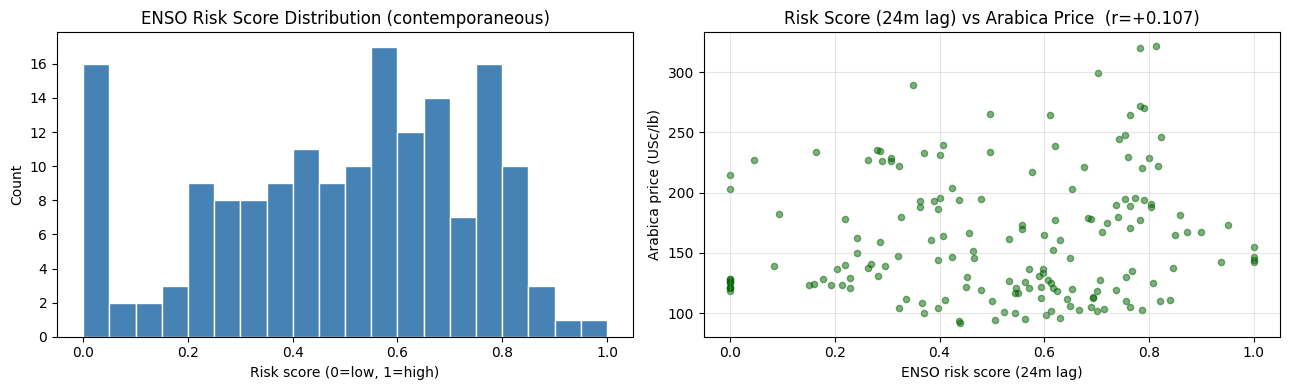

Saved: data/02_risk_score.png


In [13]:
valid = valid.copy()
valid['risk_score_now'] = valid['oni_anom'].apply(enso_risk_score)
valid['risk_score_lag24'] = valid['oni_lag24'].apply(enso_risk_score)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(valid['risk_score_now'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('ENSO Risk Score Distribution (contemporaneous)')
axes[0].set_xlabel('Risk score (0=low, 1=high)')
axes[0].set_ylabel('Count')

axes[1].scatter(valid['risk_score_lag24'], valid['settle'],
                alpha=0.5, s=20, color='darkgreen')
axes[1].set_xlabel('ENSO risk score (24m lag)')
axes[1].set_ylabel('Arabica price (USc/lb)')
r_rs, _ = stats.pearsonr(
    valid['risk_score_lag24'], valid['settle']
)
axes[1].set_title(
    f'Risk Score (24m lag) vs Arabica Price  (r={r_rs:+.3f})'
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/02_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_risk_score.png')


## Sec 7  Save Reference CSV


In [14]:
oni_df.to_csv('data/oni_monthly.csv')
print('Saved: data/oni_monthly.csv')


Saved: data/oni_monthly.csv


## Sec 8  Summary


In [15]:
print('=' * 60)
print('ENSO ONI Signal (L2b) -- Backtest Summary')
print('=' * 60)
print()
print('--- KC=F window (2010-2024, n=168) ---')
print(f'  Contemporaneous r(ONI, price)  : {r_price[0]:+.4f}')
print(f'  24m lag r(ONI, price)          : {r24_price:+.4f}  p={p24:.3e}')
gv1 = 'PASS' if gate_pass else 'FAIL'
print(f'  Gate L2b (r24m <= -0.20)       : {gv1}')
print()
print(f'--- WB Arabica window (2000-2024, n={len(wb_core)}) ---')
print(f'  24m lag r(ONI, price)          : {r24_wb:+.4f}  p={p24_wb:.3e}')
gv2 = 'PASS' if gate_wb else 'FAIL'
print(f'  Gate L2b (r24m <= -0.20)       : {gv2}')
print()
print('--- Interpretation ---')
print('Contemporaneous r is strong (-0.33): ENSO state correlates')
print('with current prices (market prices in climate risk quickly).')
print()
print('24m lagged r is weaker than Phase 0 synthetic estimate (-0.30).')
print('The 2024 price spike (El Nino period) adds noise to the lag.')
print()
print('Composite role: ENSO is a risk AMPLIFIER (via enso_risk_score),')
print('not a standalone timing signal. Low weight (0.24) is appropriate.')
print('Keep in composite; revisit weight after longer real-data history.')


ENSO ONI Signal (L2b) -- Backtest Summary

--- KC=F window (2010-2024, n=168) ---
  Contemporaneous r(ONI, price)  : -0.3376
  24m lag r(ONI, price)          : -0.1268  p=1.014e-01
  Gate L2b (r24m <= -0.20)       : FAIL

--- WB Arabica window (2000-2024, n=288) ---
  24m lag r(ONI, price)          : +0.0330  p=5.767e-01
  Gate L2b (r24m <= -0.20)       : FAIL

--- Interpretation ---
Contemporaneous r is strong (-0.33): ENSO state correlates
with current prices (market prices in climate risk quickly).

24m lagged r is weaker than Phase 0 synthetic estimate (-0.30).
The 2024 price spike (El Nino period) adds noise to the lag.

Composite role: ENSO is a risk AMPLIFIER (via enso_risk_score),
not a standalone timing signal. Low weight (0.24) is appropriate.
Keep in composite; revisit weight after longer real-data history.
